# DSE 200 FINAL PROJECT
## Fall 2025
### Due Date: November 21th, 2025

This project is culmination of all you’ve learned in this course! You should expect to spend <b>24-32 total hours</b> on the project. Be sure to read all of the items below before starting.

There are a number of steps outlined below, but is critical that you do not view this as an entirely linear process.  Remember that the science component in data science is the creation of a hypothesis based on exploration and testing of that hypothesis through analysis.  You may need to go through many of these steps multiple times before you arrive at meaningful hypothesis or conclusions.

## Step 1: Find a dataset or datasets

Based on your interest, identify a dataset which you will want to examine.  You will find a starting point for where you can find open datasets at the end of this notebook, but feel free to use other datasets you have access to and can publicly share results about.


This step may take some time, as you’ll likely look at a number of datasets before you find one (or more) which holds promising data for the kinds of questions you want to ask. You are expected to use at least two interconnected datasets, e.g., two tables in one database or a combination of datasets which you can merge in some meaningful way.


In [2]:
#EXPLAIN AND INGEST YOUR DATASET IN THIS SECTION

Let's import what we'll need

In [3]:
!pip install backtesting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/192.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 8.0 MB/s eta 0:00:00


In [76]:
import kagglehub
import os
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
import backtesting
from sklearn.ensemble import RandomForestClassifier


Donwload what we need from kaggle

In [2]:

# Download latest version
path = kagglehub.dataset_download("mattiuzc/stock-exchange-data")

path2 = kagglehub.dataset_download("saketk511/world-important-events-ancient-to-modern")

print("Path to dataset files:", path)

#with open(path)

Path to dataset files: C:\Users\jlu2\.cache\kagglehub\datasets\mattiuzc\stock-exchange-data\versions\2


Load the Data info dataframes

In [3]:
df_data = pd.read_csv(os.path.join(path, "indexData.csv"))
df_info = pd.read_csv(os.path.join(path, "indexInfo.csv"))
df_processed = pd.read_csv(os.path.join(path, "indexProcessed.csv"))
# df_events = pd.read_csv(os.path.join(path2, "World Important Dates.csv"))

df_events = pd.read_csv(
    os.path.join(path2, "World Important Dates.csv"),
    engine="python",
    quotechar='"',
    skipinitialspace=True
)
# df_events = pd.read_csv(
#     os.path.join(path2, "World Important Dates.csv"),
#     engine="python",
#     quotechar='"',
#     skipinitialspace=True,
#     on_bad_lines="skip"    # or "warn"
# )


In [7]:
#PERFORM AND EXPLAIN YOUR EXPLORATORY ANALYSIS IN THIS SECTION

### Data overview
indexData.csv: daily price + volume data for major global indices

indexInfo.csv: metadata: region, exchange, currency, index name

indexProcessed.csv: cleaned version of the price data with USD-normalized closes (CloseUSD)

### Explaination of data analysis
- Looking for data shape, content, & quality issues

From the review we can see that while df_data has the only missing values which also are only numeric columns, the df_processed has been cleaned of all the missing data issues.
Next we'll check the size of the dataframe before the merge and then after to make sure we don't have any loss.

## Step 2: Explore the datasets

In this step, you should explore what is present in the data and how the data is organized. You’ll need to determine what common features allow you to merge the datasets.  

You are expected to answer the following questions using the _pandas_ library and markdown cells to describe your actions:

* Are there quality issues in the dataset (noisy, missing data, etc.)?
* What will you need to do to clean and/or transform the raw data for analysis?

You are also expected to use the _matplotlib_ library to visually explore the datasets and explain your findings, specifically,

* How are the data distributed?
* What are some common trends?
* What are the relationships between variables in your datasets?

### Clean up the df_events and df_data Dataframes

In [4]:
df_data['Date'] = pd.to_datetime(df_data['Date'])

In [5]:
df_data['Year'] = df_data['Date'].dt.year
df_data['Month'] = df_data['Date'].dt.month
df_data['Day'] = df_data['Date'].dt.day

In [6]:
# Adding in more features

# Prediction value = Profit
# df_data['p_gain'] = (df_data['Open'] - df_data['Close']) / df_data['Close'] * 100
df_data['Daily_Return'] = df_data.groupby('Index')['Adj Close'].pct_change()
df_data['day_change'] = df_data.groupby('Index')['Adj Close'].diff()
df_data['up'] = df_data.day_change.apply(lambda x: x if x >0 else 0)
df_data['down'] = np.abs(df_data.day_change.apply(lambda x: x if x <0 else 0))
df_data['median'] = (df_data['High'] - df_data['Low']) /2

# Volatility_5D = std of last 5 daily returns
df_data['Volatility_5D'] = (df_data['Daily_Return'].rolling(window=5).std().reset_index(level=0, drop=True))

# Volatility_10D
df_data['Volatility_10D'] = (df_data['Daily_Return'].rolling(window=10).std().reset_index(level=0, drop=True))

# Combined the Rolling_Avg_Adj Close_50D with Trend Distance (how far above / below trend is the market
df_data['SMA_50'] = (df_data['Adj Close'].rolling(window=50).mean().reset_index(level=0, drop=True))
df_data['Dist_from_SMA50'] = df_data['Adj Close'] / df_data['SMA_50'] - 1

# Combined the Rolling_Avg_Adj Close_200D with Trend Distance (how far above / below trend is the market
df_data['SMA_200'] = (df_data['Adj Close'].rolling(window=200).mean().reset_index(level=0, drop=True))
df_data['Dist_from_SMA200'] = df_data['Adj Close'] / df_data['SMA_200'] - 1

# Volume_Change (pct change) in market activity
df_data['Volume_Change'] = (df_data['Volume'].pct_change())

# Range = High − Low (shows a raw measure how volatile the day was)
df_data['Range'] =  df_data['High'] - df_data['Low']

# Intraday_Volatility = (High − Low) / Open (shows a standardized measure how volatile the day was by opening price in a single day)
df_data['Intraday_Volatility'] =  (df_data['High'] - df_data['Low']) / (df_data['Open'])

# RS and RSI
df_data['RS'] = (df_data['up'].rolling(window=14).mean().reset_index(level=0, drop=True)) /\
                (df_data['down'].rolling(window=14).mean().reset_index(level=0, drop=True))

df_data['RSI'] = 100 - (100/(1 + df_data['RS']))
# Momentum Oscilator

df_data['momentum'] = (df_data['median'].rolling(window=5).mean().reset_index(level=0, drop=True)) -\
                      (df_data['median'].rolling(window=34).mean().reset_index(level=0, drop=True))



C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\2949547169.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_data['Daily_Return'] = df_data.groupby('Index')['Adj Close'].pct_change()
C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\2949547169.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_data['Volume_Change'] = (df_data['Volume'].pct_change())


##### get rid of BC years in events

In [11]:
df_events = df_events.loc[~df_events.Year.astype(str).str.contains('BC')]
df_events['Year'] = df_events['Year'].astype(int)

C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\1721820033.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_events['Year'] = df_events['Year'].astype(int)


#### Create general category for "Type of Event"

In [12]:
#sort events by more general category....imported level of detail is a bit much
df_events['category'] = ''
df_events['Type of Event'] = df_events['Type of Event'].str.lower()
df_events.loc[df_events['Type of Event'].str.contains('partition|violent|conquest|foundational|dictator|referendum|war dec|unification|adminis|nationalization|coup|annex|terror|insurgen|revolt|policy|peace|leglis|constitut|political movement|admin|disobedi|diplo|politic|treaty|rights|refer|corrupt|agree|protest|'), 'category'] = 'violent political'
df_events.loc[df_events['Type of Event'].str.contains('ceasefire|independ|military|war|battle|engagement|conflict|test'), 'category'] = 'military'
df_events.loc[df_events['Type of Event'].str.contains('massacre|execution|incident|disaster|accident|pandemic|genocide|pogrom'), 'category'] = 'disaster'
df_events.loc[df_events['Type of Event'].str.contains('scien|education|agricul|conserva|achiev|rescue|integration|implement|effort|change|discovery|natural|artistic|reform|medical|humanitar|develop|marvel|engineer|tech'), 'category'] = 'achievement'
df_events.loc[df_events['Type of Event'].str.contains('sporting|trade|economi|social|international|cultur|decline|health'), 'category'] = 'socioeconomic'
df_events.loc[df_events['Type of Event'].str.contains('religio'), 'category'] = 'religious'
df_events.loc[((df_events.category.str.contains('polit')) & (df_events.Outcome == 'Positive')), 'category'] = 'peaceful political'

# #encode "outcome to -1 if negative, 0 if mixed, 1 if positive"
df_events['eOutcome'] = 0
df_events.loc[df_events['Outcome'].str.contains('Neg'), 'eOutcome'] = -1
df_events.loc[df_events['Outcome'].str.contains('Mixed|Ongoing'), 'eOutcome'] = 0
df_events.loc[df_events['Outcome'].str.contains('Pos'), 'eOutcome'] = 1


C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\1132341896.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_events['category'] = ''
C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\1132341896.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_events['Type of Event'] = df_events['Type of Event'].str.lower()
C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\1132341896.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [13]:
#m...modestly even distribution of events between political/war. Not so much the other stuff thoug h
df_events.groupby('category').count()

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,eOutcome
category,,,,,,,,,,,,,
achievement,93,93,93,93,93,93,93,93,93,93,93,93,93
disaster,30,30,30,30,30,30,30,30,30,30,30,30,30
military,238,238,232,238,238,238,238,238,238,238,238,238,238
peaceful political,288,288,286,288,288,288,288,288,288,288,288,288,288
religious,21,21,21,21,21,21,21,21,21,21,21,21,21
socioeconomic,204,204,194,204,204,204,204,204,204,204,204,204,204
violent political,215,215,207,215,215,215,215,215,215,215,215,215,215


#### Group by Index and Year, Aggregate features, Create Yearly price change

In [8]:
def percentile(n):
    def percentile_(x):
        return x.quantile(n)
    percentile_.__name__ = 'percentile_{:02.0f}'.format(n*100)
    return percentile_

#group by index and year, get rid of unecessary columns, agg mean, median, and stdev, flatten indices. 
def aggregator(df, groupby = ['Index','Year'], aggs = ['min','max','mean','median','std', 'sum']):
    df2 = df.groupby(groupby).agg(aggs)
    df2.columns = ['_'.join(col).strip() for col in df2.columns.values]
    df2.columns = df2.columns.to_flat_index()
    df2.reset_index(inplace=True)
    if 'Index' in groupby:
        df2['year_index'] = df2['Year'].astype(str) + '_' + df2['Index']
    print(df2.shape)
    return df2

def start_end_dfs(df, month=1, year = False):
    if year:
        startdf = aggregator(df.loc[(df_data.Date.dt.month==1)], aggs = ['min','max','mean','median','std', percentile(0.1), percentile(0.9)])
        enddf = aggregator(df.loc[(df_data.Date.dt.month==12)], aggs = ['min','max','mean','median','std', percentile(0.1), percentile(0.9)])
        return startdf, enddf       
    else:
        startdf = aggregator(df.loc[(df.Date.dt.month==month) & (df.Date.dt.day.isin([1,2,3,4,5,6,7]))], \
                         aggs = ['min','max','mean','median','std', percentile(0.1), percentile(0.9)])
        enddf = aggregator(df.loc[(df.Date.dt.month==month) & (df.Date.dt.day.isin([25,26,27,28,29,30,31]))], \
                       aggs = ['min','max','mean','median','std', percentile(0.1), percentile(0.9)])
        return startdf, enddf

def gains(df, month=0, year=False):
    if month !=0:
        start_df, end_df = start_end_dfs(df, month)
        gain_df = end_df.merge(start_df, how='left', left_on=['year_index'], right_on='year_index', suffixes=['_end', '_start'])
        gain_df['month_pgain'] = (gain_df['Adj Close_mean_end'] - gain_df['Adj Close_mean_start']) / gain_df['Adj Close_mean_start'] * 100
        gain_df['buylowsellhigh_pgain'] = (gain_df['Close_percentile_90_end'] - gain_df['Adj Close_percentile_10_start']) / gain_df['Adj Close_percentile_10_start'] * 100
        gain_df = gain_df.loc[~gain_df['month_pgain'].isna()] #drop these years because they're the start of the dataset
        return gain_df
        
    if year: 
        start_df, end_df = start_end_dfs(df, year = True)
        gain_df = end_df.merge(start_df, how='left', left_on=['year_index'], right_on='year_index', suffixes=['_end', '_start'])
        gain_df['year_pgain'] = (gain_df['Adj Close_mean_end'] - gain_df['Adj Close_mean_start']) / gain_df['Adj Close_mean_start'] * 100
        gain_df['year_sum_pgain'] = (gain_df['Adj Close_mean_end'] - gain_df['Adj Close_mean_start']) / gain_df['Adj Close_mean_start'] * 100
        gain_df = gain_df.loc[~gain_df['year_pgain'].isna()] #drop these years because they're the start of the dataset
        return gain_df
        

### Agg stock and event dataframes by year

- agg stocks and events. Create seperate dataframes to find year gain
- Get high and low for first and last month of year, find something Adj Close enough for end of year
- ...trying to align to week doesn't work cleanly due to holidays


In [14]:
events_by_year = aggregator(df_events[['Year','category','eOutcome', 'Outcome']], groupby = ['Year'], aggs = ['count','sum'])

C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(460, 187)
adjusted stocks by year (460, 92)
(325, 7)


In [15]:
#calculate profit for each month with buy at lowest in first week, sell highest at end of month, then concat
jan = gains(df_data, month = 1)
feb = gains(df_data, month = 2)
mar = gains(df_data, month = 3)
apr = gains(df_data, month = 4)
may = gains(df_data, month = 5)
jun = gains(df_data, month = 6)
jul = gains(df_data, month = 7)
aug = gains(df_data, month = 8)
sept = gains(df_data, month = 9)
octt = gains(df_data, month = 10)
nov = gains(df_data, month = 11)
dec = gains(df_data, month = 12)
year = gains(df_data, year=True)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_functio

(447, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(441, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(446, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(448, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subt

(449, 185)
(449, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(449, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(449, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(447, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(449, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(439, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(436, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(438, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(438, 185)
(438, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(439, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(439, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(440, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(411, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(440, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\

(440, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(441, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(441, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
C:\Users\jlu2\AppData\Local\Programs\Python\

(446, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4655: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4655: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered i

(447, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(446, 185)


#### Add cumulative sum to year and buy/sell month dataframes

In [16]:
#do more stuff 
year['cumsum_year'] = year.groupby('Index_end')['year_pgain'].transform('cumsum')
buysell_12month = pd.concat([jan,feb,mar,apr,jun,jul,aug,sept,octt,nov,dec])
buysell_12month = buysell_12month.select_dtypes(include=['object', 'number'])
buysell_12month = aggregator(buysell_12month[[col for col in buysell_12month if 'Index' not in col]], aggs = ['mean','sum'], groupby=['year_index'])
buysell_12month['Index'] = buysell_12month.year_index.apply(lambda x:re.sub(r'(.*)_','',x))
buysell_12month['cumsum_month'] = buysell_12month.groupby('Index')['month_pgain_mean'].transform('cumsum')
buysell_12month['cumsum_strat'] = buysell_12month.groupby('Index')['buylowsellhigh_pgain_mean'].transform('cumsum')

(455, 713)


C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\424200266.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2.reset_index(inplace=True)
C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\781149551.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  buysell_12month['Index'] = buysell_12month.year_index.apply(lambda x:re.sub(r'(.*)_','',x))
C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\781149551.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

In [17]:
#Check if we get an average of 7% return per year across the indices 
tdf = pd.DataFrame(year.groupby('Index_end')['year_pgain'].describe().mean()).T
tdf.rename(index={0: 'average'})
tdf

,count,mean,std,min,25%,50%,75%,max
0,30.928571,7.039956,23.015091,-41.3112,-5.427304,7.214422,18.401832,59.086094


#### Cumulative and % gains per year by leaving money alone 

Text(46.73384722222221, 0.5, 'Cumulative gains (%)')

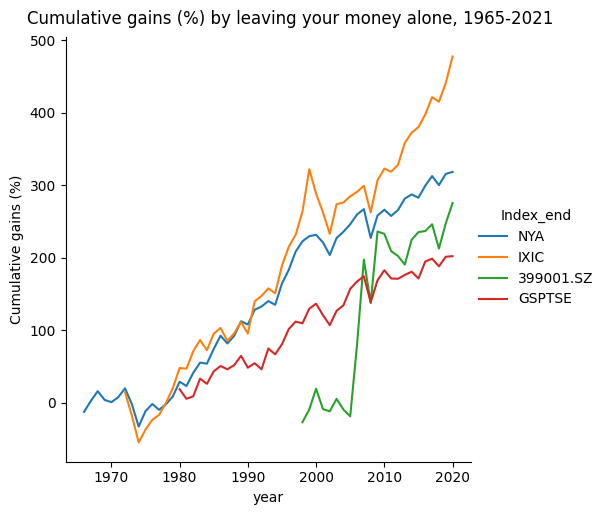

In [18]:
#cumulative % gain per year, keep your money where it is
g = sns.relplot(year.loc[year.Index_end.str.contains('NYA|IXIC|SZ|GSP')], x='Year_end', y='cumsum_year',
                hue='Index_end', 
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
                kind='line')
plt.suptitle('Cumulative gains (%) by leaving your money alone, 1965-2021', y=1.02)
plt.xlabel('year')
plt.ylabel('Cumulative gains (%)')

Text(0.5, 28.999999999999986, 'Year')

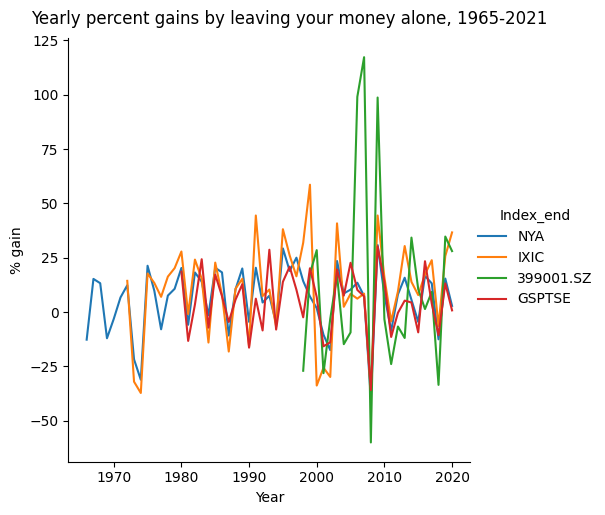

In [61]:
# % gain vs year if you leave your money alone

g = sns.relplot(year.loc[year.Index_end.str.contains('NYA|IXIC|SZ|GSP')], x='Year_end', y='year_pgain',
                hue='Index_end', 
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
                kind='line')
plt.suptitle('Yearly percent gains by leaving your money alone, 1965-2021', y=1.02)
plt.ylabel('% gain')
plt.xlabel('Year')


#### Cumulative and % gains per year when buying/selling every month

(0.0, 50.0)

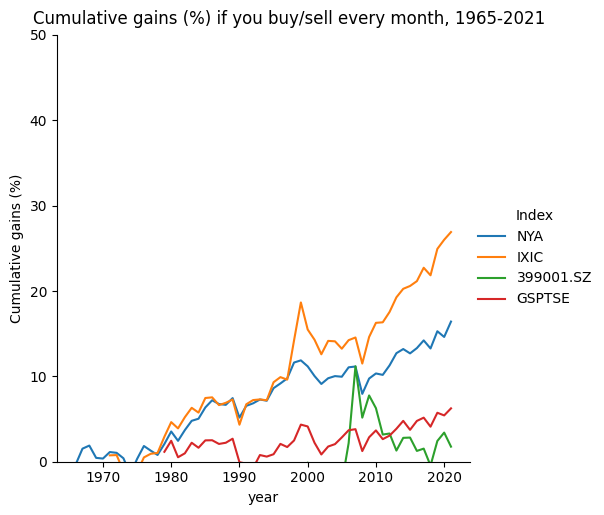

In [60]:
#Cumulative percent gain every year if you buy sell every month

g = sns.relplot(buysell_12month.loc[buysell_12month.Index.str.contains('NYA|IXIC|SZ|GSP')], x='Year_end_mean', y='cumsum_month',
                hue='Index', 
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
                kind='line')
plt.suptitle('Cumulative gains (%) if you buy/sell every month, 1965-2021', y=1.02)
plt.xlabel('year')
plt.ylabel('Cumulative gains (%)')
plt.ylim(0,50)

Text(0.5, 28.999999999999986, 'Year')

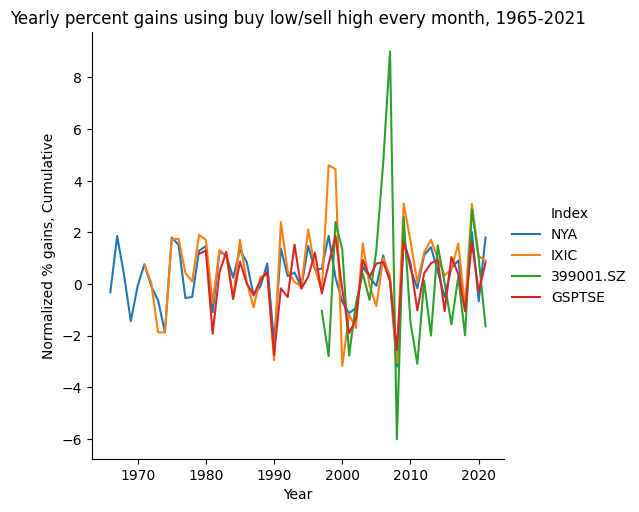

In [63]:
#pgain per year using buy/sell strategy

g = sns.relplot(buysell_12month.loc[buysell_12month.Index.str.contains('NYA|IXIC|SZ|GSP')],
                x='Year_end_mean', y='month_pgain_mean',
                kind='line',
                hue='Index',
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
               )
# plt.arrow(2000, 150, 15, -30, width=0.75)
# ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props)
plt.title('Yearly percent gains using buy low/sell high every month, 1965-2021')
plt.ylabel('Normalized % gains, Cumulative')
plt.xlabel('Year')

#### Strategy 1
##### Cumulative and %gain per year if you buy/sell every month at 10th percentile first week, 90th percentile 4th week

(0.0, 500.0)

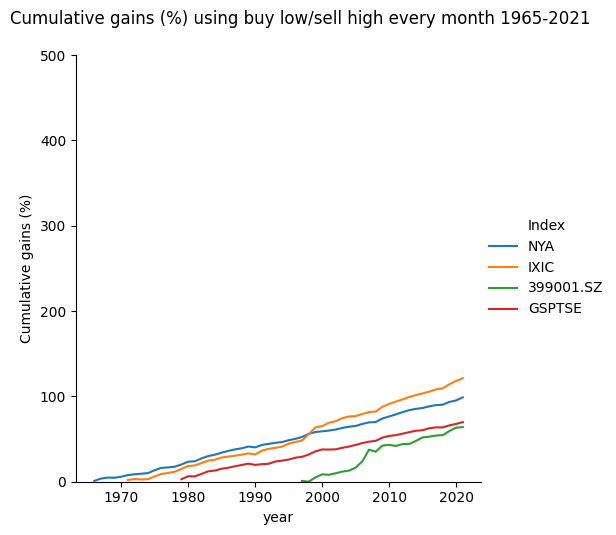

In [19]:
#cumulative % gain per year, buy/sell every month 

g = sns.relplot(buysell_12month.loc[buysell_12month.Index.str.contains('NYA|IXIC|SZ|GSP')], x='Year_end_mean', y='cumsum_strat',
                hue='Index', 
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
                kind='line')
plt.suptitle('Cumulative gains (%) using buy low/sell high every month 1965-2021', y=1.06)
plt.xlabel('year')
plt.ylabel('Cumulative gains (%)')
plt.ylim(0,500)

Text(0.5, 28.999999999999986, 'Year')

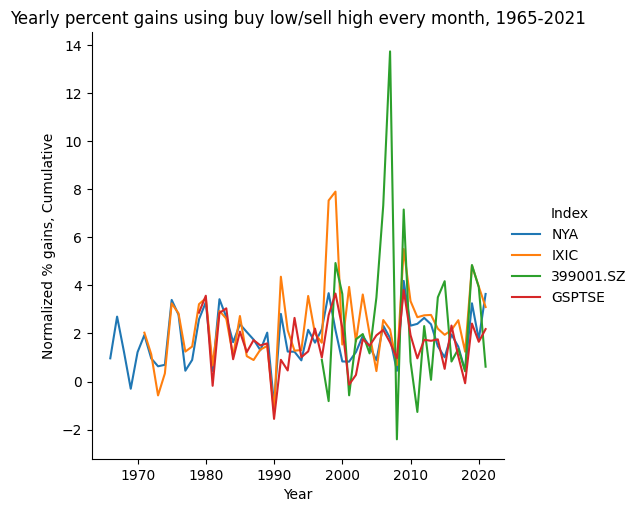

In [62]:
#pgain per year using buy/sell strategy by percntile 10/90

g = sns.relplot(buysell_12month.loc[buysell_12month.Index.str.contains('NYA|IXIC|SZ|GSP')],
                x='Year_end_mean', y='buylowsellhigh_pgain_mean',
                kind='line',
                hue='Index',
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
               )
# plt.arrow(2000, 150, 15, -30, width=0.75)
# ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props)
plt.title('Yearly percent gains using buy low/sell high every month, 1965-2021')
plt.ylabel('Normalized % gains, Cumulative')
plt.xlabel('Year')

#### Strategy 2: Golden Cross

Text(0.5, 1.0, 'Golden cross example')

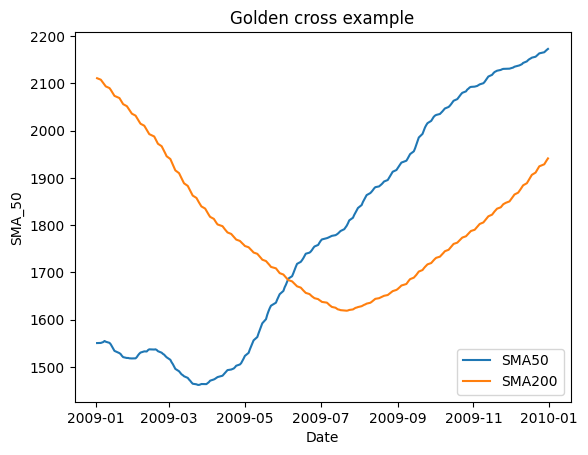

In [26]:
#golden cross example
g = sns.lineplot(df_data.loc[(df_data.Index == 'IXIC') & (df_data.Year == 2009)], x='Date', y='SMA_50', label='SMA50')
sns.lineplot(df_data.loc[(df_data.Index == 'IXIC') & (df_data.Year == 2009)], x='Date', y='SMA_200', label='SMA200')
plt.title('Golden cross example')

C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(154, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(158, 185)


Text(46.73384722222221, 0.5, 'Cumulative gains (%)')

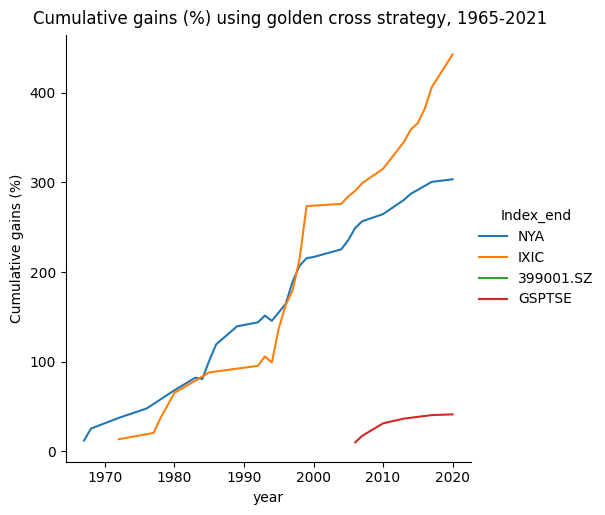

In [27]:
#Golden cross strategy, cumulative gains 
buysell_smarter1 = gains(df_data[df_data['SMA_50'] > df_data['SMA_200']], year=True)
buysell_smarter1['cumsum_year'] = buysell_smarter1.groupby('Index_end')['year_pgain'].transform('cumsum')

g = sns.relplot(buysell_smarter1.loc[buysell_smarter1.Index_end.str.contains('NYA|IXIC|SZ|GSP')], x='Year_end', y='cumsum_year',
                hue='Index_end', 
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
                kind='line')
plt.suptitle('Cumulative gains (%) using golden cross strategy, 1965-2021', y=1.02)
plt.xlabel('year')
plt.ylabel('Cumulative gains (%)')

(-60.0, 125.0)

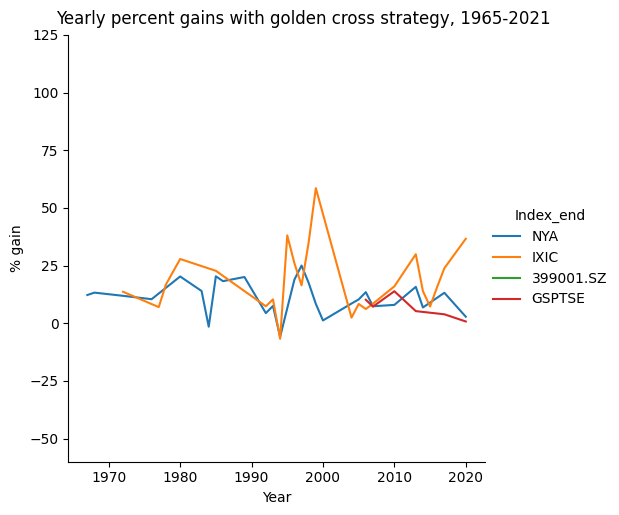

In [28]:
# % gain vs year using golden cross strategy

g = sns.relplot(buysell_smarter1.loc[buysell_smarter1.Index_end.str.contains('NYA|IXIC|SZ|GSP')], x='Year_end', y='year_pgain',
                hue='Index_end', 
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
                kind='line')
plt.suptitle('Yearly percent gains with golden cross strategy, 1965-2021', y=1.02)
plt.ylabel('% gain')
plt.xlabel('Year')
plt.ylim(-60,125)


#### Strategy 3: Momentum

Text(0.5, 1.0, 'Momentum example')

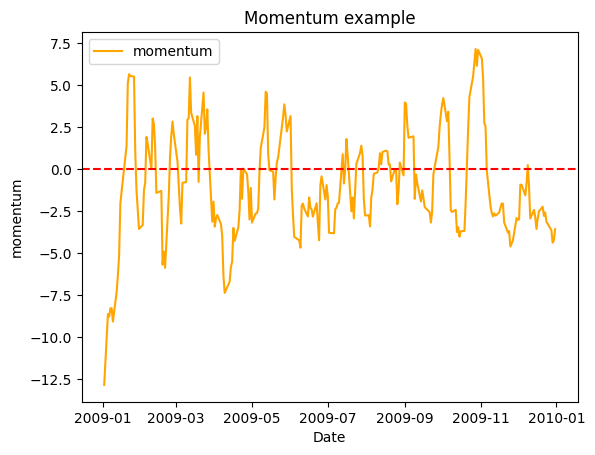

In [36]:
#momentum example
g = sns.lineplot(df_data.loc[(df_data.Index == 'IXIC') & (df_data.Year == 2009)], x='Date', y='momentum', label='momentum', color='orange')
g.axhline(y=0, color='red', ls='--')
plt.title('Momentum example')

C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(201, 185)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4655: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4655: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4656: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


(286, 185)


Text(46.73384722222221, 0.5, 'Cumulative gains (%)')

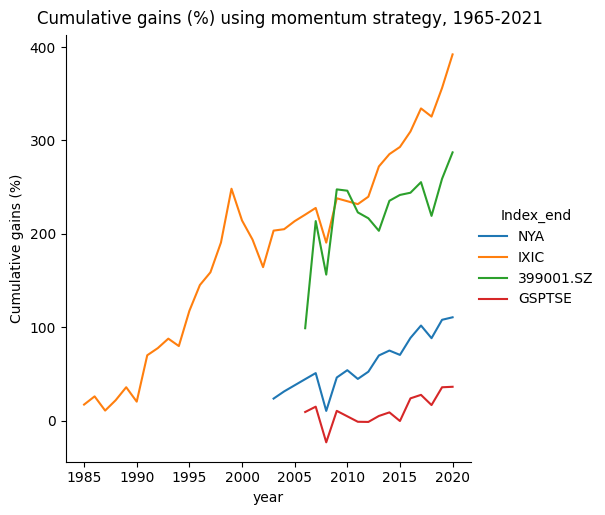

In [29]:
#momentum strategy, cumulative gains 
buysell_smarter2 = gains(df_data[df_data['momentum'] > 0], year=True)

buysell_smarter2['cumsum_year'] = buysell_smarter2.groupby('Index_end')['year_pgain'].transform('cumsum')

g = sns.relplot(buysell_smarter2.loc[buysell_smarter2.Index_end.str.contains('NYA|IXIC|SZ|GSP')], x='Year_end', y='cumsum_year',
                hue='Index_end', 
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
                kind='line')
plt.suptitle('Cumulative gains (%) using momentum strategy, 1965-2021', y=1.02)
plt.xlabel('year')
plt.ylabel('Cumulative gains (%)')


Text(0.5, 28.999999999999986, 'Year')

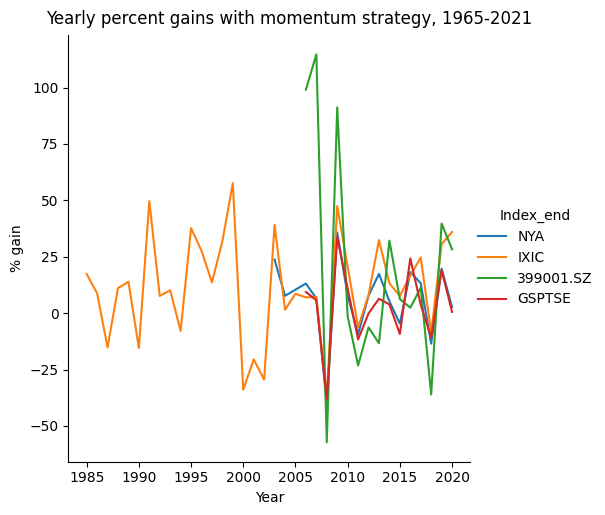

In [31]:
# % gain vs year using momentum strategy

g = sns.relplot(buysell_smarter2.loc[buysell_smarter2.Index_end.str.contains('NYA|IXIC|SZ|GSP')], x='Year_end', y='year_pgain',
                hue='Index_end', 
                hue_order = ['NYA', 'IXIC', '399001.SZ', 'GSPTSE'],
                kind='line')
plt.suptitle('Yearly percent gains with momentum strategy, 1965-2021', y=1.02)
plt.ylabel('% gain')
plt.xlabel('Year')


# Combine Dataframes with events

Text(-2, -18, 'Why are years with a lot of positive events\n showing negative yearly percent returns? ')

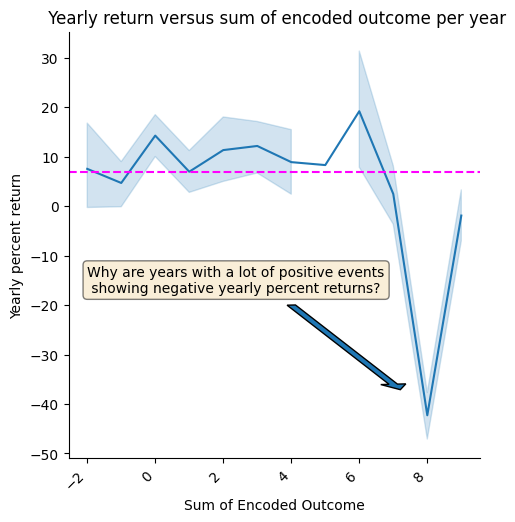

In [37]:
stocks_and_events_df = year.merge(events_by_year, how='left', left_on = 'Year_end', right_on = 'Year')

sns.relplot(stocks_and_events_df,
             x='eOutcome_sum',
             y='year_pgain',
             # size = 'Outcome_count',
             sizes=(10, 100),
             kind='line'
             # hue = 'eOutcome_median',
             # palette=['red','orangered','gold','yellowgreen','green']
           )
plt.xticks(rotation=45, ha='right')
plt.axhline(y=7, color='magenta', ls='--')
plt.xlabel('Sum of Encoded Outcome')
plt.ylabel('Yearly percent return')
plt.title(' Yearly return versus sum of encoded outcome per year')
plt.arrow(4,-20,3,-16, width=0.25)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(-2, -18, 'Why are years with a lot of positive events\n showing negative yearly percent returns? ', fontsize=10,
        verticalalignment='bottom', bbox=props)

In [38]:
stocks_and_events_df.loc[stocks_and_events_df.eOutcome_sum > 7].Year.unique()

array([2008, 2010, 2018, 1975])

#### Inspect and clean data for nan

In [47]:
null_summary = stocks_and_events_df.isnull().agg(['sum','mean']).T
null_summary.columns = ['null_count','null_percent']
null_summary = null_summary[null_summary['null_count'] > 0]
null_summary

,null_count,null_percent
SMA_50_min_end,83.0,0.191686
SMA_50_max_end,83.0,0.191686
SMA_50_mean_end,83.0,0.191686
SMA_50_median_end,83.0,0.191686
SMA_50_std_end,84.0,0.193995
...,...,...
momentum_mean_start,191.0,0.441109
momentum_median_start,191.0,0.441109
momentum_std_start,191.0,0.441109
momentum_percentile_10_start,191.0,0.441109


In [62]:
for col in null_summary.index:
    print(col, null_summary.loc[col].to_dict())

SMA_50_min_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
SMA_50_max_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
SMA_50_mean_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
SMA_50_median_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
SMA_50_std_end {'null_count': 84.0, 'null_percent': 0.19399538106235567}
SMA_50_percentile_10_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
SMA_50_percentile_90_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
Dist_from_SMA50_min_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
Dist_from_SMA50_max_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
Dist_from_SMA50_mean_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
Dist_from_SMA50_median_end {'null_count': 83.0, 'null_percent': 0.19168591224018475}
Dist_from_SMA50_std_end {'null_count': 84.0, 'null_percent': 0.19399538106235567}
Dist_from_SMA50_percentile_10_end {'null_count': 83

Drop NAs for now to run the model (may need to adjust)

In [85]:
for col in stocks_and_events_df.columns:
    print(col)

Index_end
Year_end
Date_min_end
Date_max_end
Date_mean_end
Date_median_end
Date_std_end
Date_percentile_10_end
Date_percentile_90_end
Open_min_end
Open_max_end
Open_mean_end
Open_median_end
Open_std_end
Open_percentile_10_end
Open_percentile_90_end
High_min_end
High_max_end
High_mean_end
High_median_end
High_std_end
High_percentile_10_end
High_percentile_90_end
Low_min_end
Low_max_end
Low_mean_end
Low_median_end
Low_std_end
Low_percentile_10_end
Low_percentile_90_end
Close_min_end
Close_max_end
Close_mean_end
Close_median_end
Close_std_end
Close_percentile_10_end
Close_percentile_90_end
Adj Close_min_end
Adj Close_max_end
Adj Close_mean_end
Adj Close_median_end
Adj Close_std_end
Adj Close_percentile_10_end
Adj Close_percentile_90_end
Volume_min_end
Volume_max_end
Volume_mean_end
Volume_median_end
Volume_std_end
Volume_percentile_10_end
Volume_percentile_90_end
Month_min_end
Month_max_end
Month_mean_end
Month_median_end
Month_std_end
Month_percentile_10_end
Month_percentile_90_end
Day_m

In [115]:
df_clean = stocks_and_events_df[['Daily_Return_mean_end', 'Range_mean_end', 'Volume_Change_mean_end',
                                 'eOutcome_sum', 'RSI_mean_start', 'SMA_50_std_start', 'category_count']]
df_clean.isnull().sum()

Daily_Return_mean_end       0
Range_mean_end              0
Volume_Change_mean_end    158
eOutcome_sum                0
RSI_mean_start              0
SMA_50_std_start          193
category_count              0
dtype: int64

#### Generate correlation tables for data exploration

In [116]:
num_df = stocks_and_events_df.select_dtypes(include=['float64', 'int64'])

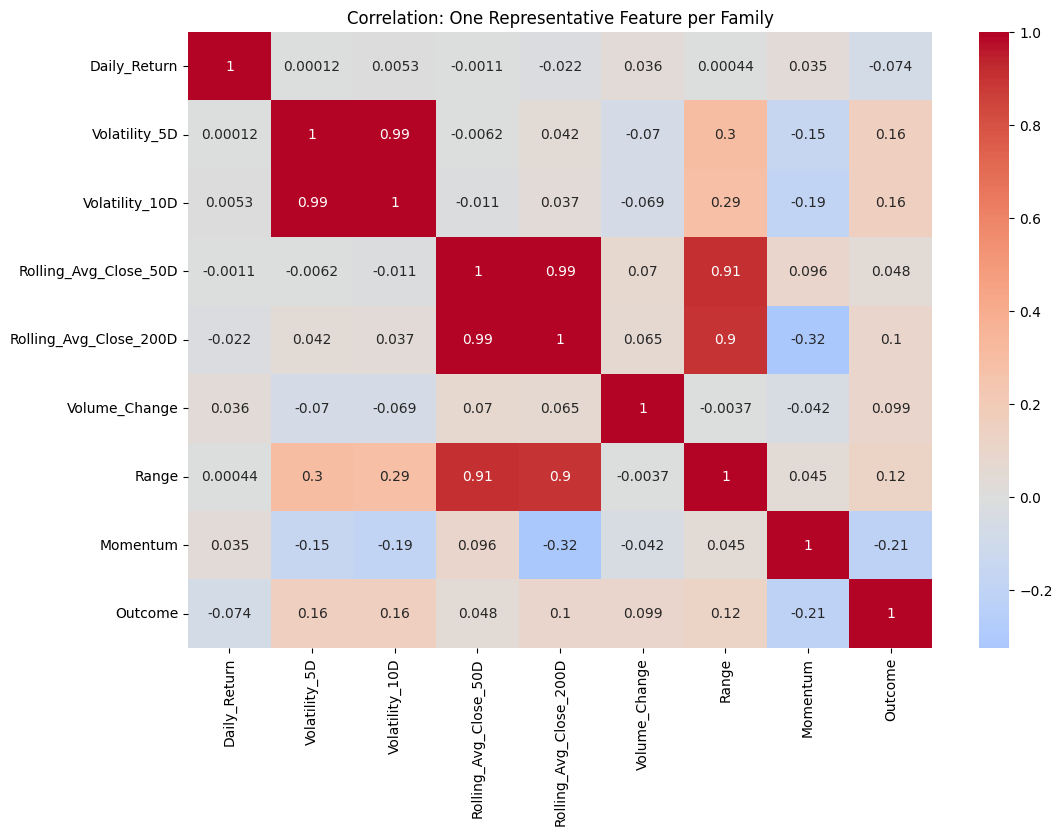

In [117]:
# --- A. ONE FEATURE PER FAMILY (HAND-PICKED REPRESENTATIVES) ---

agg_df = pd.DataFrame(index=num_df.index)

# Short-term return / target-adjacent
agg_df['Daily_Return'] = num_df['Daily_Return_mean_end']

# Volatility
agg_df['Volatility_5D']  = num_df['Volatility_5D_mean_end']
agg_df['Volatility_10D'] = num_df['Volatility_10D_mean_end']

# Trend indicators (moving averages)
agg_df['Rolling_Avg_Close_50D']  = num_df['SMA_50_mean_end']
agg_df['Rolling_Avg_Close_200D'] = num_df['SMA_200_mean_end']

# Volume change
agg_df['Volume_Change'] = num_df['Volume_Change_mean_end']

# Range (daily high-low spread)
agg_df['Range'] = num_df['Range_mean_end']

# Momentum
agg_df['Momentum'] = num_df['momentum_mean_end']

# Optional: include your target
agg_df['Outcome'] = num_df['eOutcome_sum']


# --- Visualize ---
plt.figure(figsize=(12, 8))
sns.heatmap(
    agg_df.corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Correlation: One Representative Feature per Family")
plt.show()


We organized ~400 engineered features into ~10 major families, such as volatility, range, momentum, and moving averages. This helps avoid redundancy and simplifies interpretation.

C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


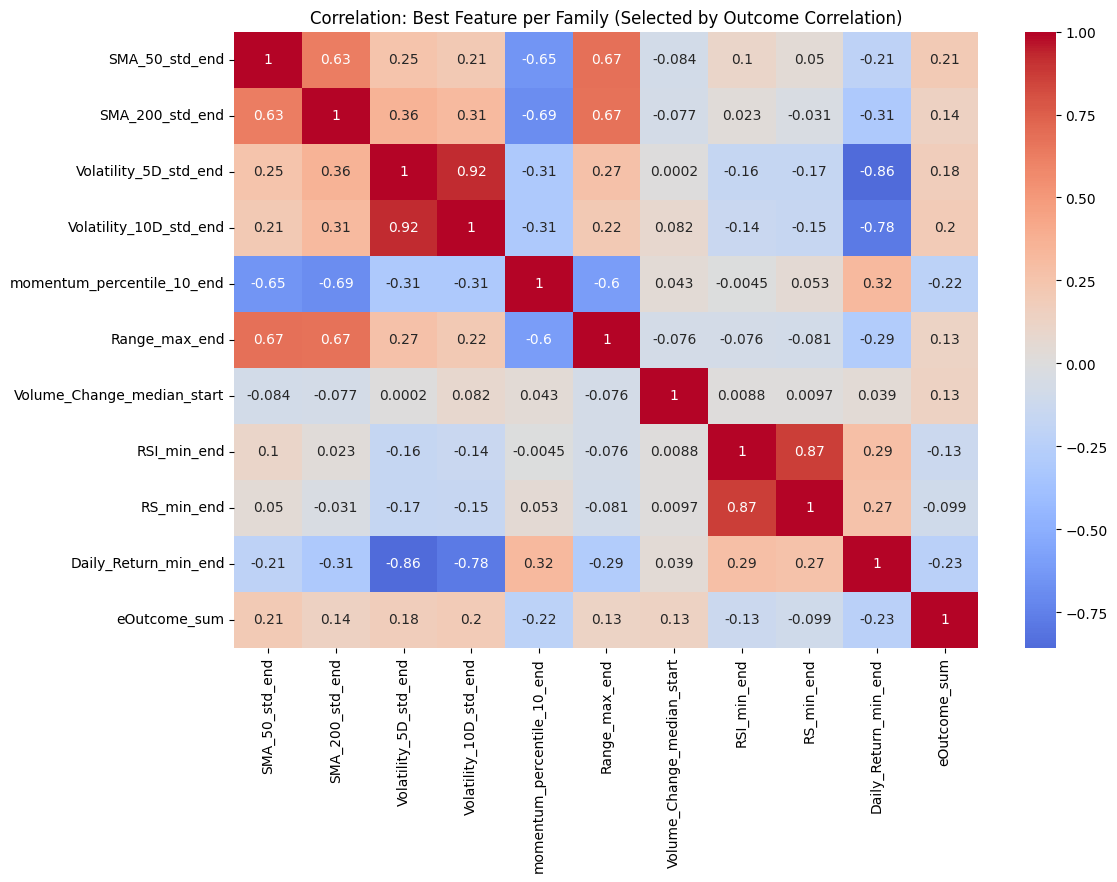

In [118]:
# --- C. BEST FEATURE PER FAMILY (CHOSEN BY CORRELATION WITH TARGET) ---

target = 'eOutcome_sum'

# Define feature families based on name prefixes
families = {
    'SMA_50':        num_df.filter(regex='^SMA_50_'),
    'SMA_200':       num_df.filter(regex='^SMA_200_'),
    'Vol_5D':        num_df.filter(regex='^Volatility_5D_'),
    'Vol_10D':       num_df.filter(regex='^Volatility_10D_'),
    'Momentum':      num_df.filter(regex='^momentum_'),
    'Range':         num_df.filter(regex='^Range_'),
    'Volume_Change': num_df.filter(regex='^Volume_Change_'),
    'RSI':           num_df.filter(regex='^RSI_'),
    'RS':            num_df.filter(regex='^RS_'),
    'Daily_Return':  num_df.filter(regex='^Daily_Return_')
}

best_features = {}

for name, group in families.items():
    if group.shape[1] == 0:
        continue  # skip empty groups
    corrs = group.corrwith(num_df[target]).abs()
    best_col = corrs.idxmax()
    best_features[name] = best_col

# Create dataframe with only best-per-family columns
best_df = num_df[list(best_features.values()) + [target]]

# --- Visualize ---
plt.figure(figsize=(12, 8))
sns.heatmap(
    best_df.corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Correlation: Best Feature per Family (Selected by Outcome Correlation)")
plt.show()


While each feature family contains many variants, we automatically selected the single metric per family that had the strongest correlation with the outcome. This lets us compare how predictive each family actually is.

## Step 3:  Identify 1-3 research questions and perform analysis

### How does the market react to world events?

### Is it better to buy and hold, or is it better to buy low/sell high every month?
- Compare golden cross vs RSI strategy using buy/hold S&P500 as benchmark



We are picking some select features to now clean in model
- Daily_Return, Range, Volume_Change

In [119]:
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.fillna(0)

In [120]:
#OVERVIEW YOUR QUESTION AND PERFORM YOUR ANALYSIS IN THIS SECTION

In [121]:
df_clean['eOutcome_sum'].unique()

array([ 2,  3, -1,  0, -2,  4,  8,  9,  1,  7,  6,  5])

#### Recreate sentiment column to help logisitic model perform better

In [122]:
df_clean.loc[df_clean['eOutcome_sum']==0, "Sentiment"] = 0
df_clean.loc[df_clean['eOutcome_sum']>0, "Sentiment"] = 1
df_clean.loc[df_clean['eOutcome_sum']< 0, "Sentiment"] = -1

Classification Model

In [123]:
df_model = df_clean.copy()
#X = df_model[list(best_features.values())]
X = df_model.drop(columns=['Sentiment','eOutcome_sum'])
y = df_model['Sentiment']

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [125]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [126]:
log_clf = LogisticRegression(
    multi_class='multinomial',
    class_weight='balanced',   # important for -1/0/1 imbalance
    max_iter=2000
)

log_clf.fit(X_train_scaled, y_train)


C:\Users\jlu2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'multinomial'


In [127]:
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)

rf_clf.fit(X_train, y_train)   # RF does NOT use scaled data


,n_estimators,400
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n",
      classification_report(y_test, log_clf.predict(X_test_scaled)))

print("Random Forest:\n",
      classification_report(y_test, rf_clf.predict(X_test)))


Logistic Regression:
               precision    recall  f1-score   support

        -1.0       0.30      0.67      0.42        24
         0.0       0.12      0.45      0.19        11
         1.0       0.80      0.16      0.27        74

    accuracy                           0.30       109
   macro avg       0.41      0.43      0.29       109
weighted avg       0.62      0.30      0.29       109

Random Forest:
               precision    recall  f1-score   support

        -1.0       0.56      0.38      0.45        24
         0.0       0.86      0.55      0.67        11
         1.0       0.78      0.91      0.84        74

    accuracy                           0.75       109
   macro avg       0.73      0.61      0.65       109
weighted avg       0.74      0.75      0.73       109



In [129]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

print("LR Accuracy:", accuracy_score(y_test, log_clf.predict(X_test_scaled)))
print("LR Balanced Accuracy:", balanced_accuracy_score(y_test, log_clf.predict(X_test_scaled)))

print("RF Accuracy:", accuracy_score(y_test, rf_clf.predict(X_test)))
print("RF Balanced Accuracy:", balanced_accuracy_score(y_test, rf_clf.predict(X_test)))


LR Accuracy: 0.30275229357798167
LR Balanced Accuracy: 0.4277914277914278
RF Accuracy: 0.7522935779816514
RF Balanced Accuracy: 0.6086199836199836


In [130]:
from sklearn.metrics import roc_auc_score

# Need probability predictions
lr_probs = log_clf.predict_proba(X_test_scaled)
rf_probs = rf_clf.predict_proba(X_test)

print("LR AUC (OvR):", roc_auc_score(y_test, lr_probs, multi_class='ovr'))
print("RF AUC (OvR):", roc_auc_score(y_test, rf_probs, multi_class='ovr'))


LR AUC (OvR): 0.5902562744999719
RF AUC (OvR): 0.8617686468526805


## Step 4:  Present your findings

In this step, you can begin to report your findings.  What did you learn from the data and how do your findings help answer your research question?  Use _matplotlib_ visualizations to present these findings.


__Remember:__ Rarely will a single data analysis conclusively answer a research question.  Here, you need to identify possible limitations.  For example, are your results limited to a certain area, city, or country?  Are you making assumptions about the data which may, or may not, be valid (e.g., that students in one term are equally qualified as students in another)?  Document these limitations in a few paragraphs.


In [131]:
#EXPAND THIS SECTION TO PRESENT YOUR FINDINGS

C:\Users\jlu2\AppData\Local\Temp\ipykernel_7264\471001444.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")


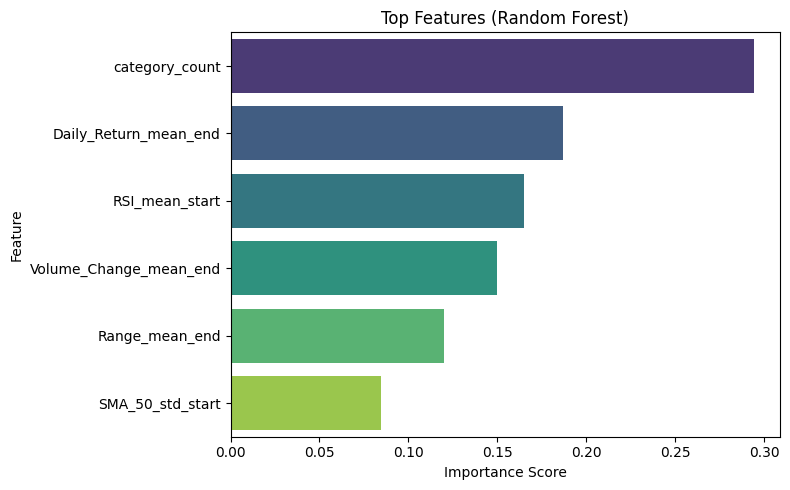

In [132]:
importances = rf_clf.feature_importances_
feat_names = X.columns

imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")
plt.title("Top Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


From this smaller feature set, the model is basically saying:

The strongest clue is whether the stock generally went up or down during the event window. If the average return was positive, sentiment tended to be positive; if it drifted down, sentiment skewed negative.

The next biggest clue is how trading volume changed. Big spikes or drops in volume often happen when investors react strongly to news, and that behavior lines up with shifts in sentiment.

Together, that means the model is relying mostly on price trend and investor activity to decide whether the market’s reaction was positive, negative, or neutral.

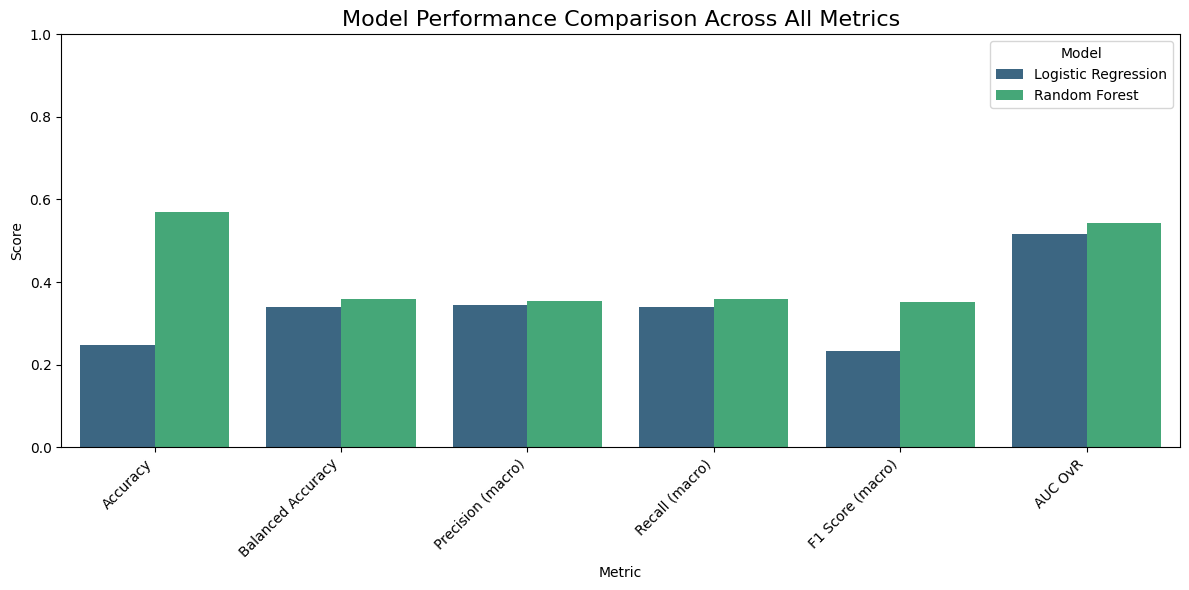

,Model,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 Score (macro),AUC OvR
0,Logistic Regression,0.247706,0.339783,0.345055,0.339783,0.233181,0.516333
1,Random Forest,0.568807,0.359029,0.354418,0.359029,0.351777,0.542448


In [82]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

# Evaluate each model
def evaluate_model(model, X_eval, y_eval, model_name):
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, preds),
        "Precision (macro)": precision_score(y_eval, preds, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_eval, preds, average="macro", zero_division=0),
        "F1 Score (macro)": f1_score(y_eval, preds, average="macro", zero_division=0),
        "AUC OvR": roc_auc_score(y_eval, probs, multi_class="ovr")
    }

# Build performance rows
results = []
results.append(evaluate_model(log_clf, X_test_scaled, y_test, "Logistic Regression"))
results.append(evaluate_model(rf_clf, X_test, y_test, "Random Forest"))

perf_df = pd.DataFrame(results)

# Visual comparisin


# Melt the dataframe for seaborn
perf_melt = perf_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=perf_melt, x="Metric", y="Score", hue="Model", palette="viridis")

plt.title("Model Performance Comparison Across All Metrics", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

perf_df


Insights: Logistic Regression

– More stable across classes

- Higher balanced accuracy

- Better recall and F1

- Better precision (handled the uneven class distribution more consistently)

- LR stayed steadier because, with only three broad features, the linear boundary generalizes better and avoids overfitting to the dominant class.

Insights: Random Forest

– Higher raw accuracy
– Slightly higher AUC
– Feature importance clearly aligned with short-term price behavior
( Daily_Return_mean_end, Volume_Change_mean_end, Range_mean_end )

RF definitely picked up real structure in the data, but:

It struggled with minority classes (lower balanced accuracy)

It overfit more easily due to the small feature set

Most of its accuracy advantage came from predicting the majority outcome well

In summary

With only three core features, both models show early signs of learnable signal, but the restricted feature space limits overall predictive power. Logistic Regression generalizes more fairly across all classes, while Random Forest captures stronger directional patterns but sacrifices balance. These results point toward expanding the feature set again and running deeper tuning in the next modeling phase.